# All environments — foundation models as dynamics models

Every environment at once, in the same structure as the per-environment notebooks
in the subfolders: the plots are the same functions with more panels.

Everything below is read from `<env>/results/*.csv`, produced in one command by

```
python experiments/dyna_standard/run_all.py
```

**1** the environments · **1b** what the model is actually handed · **2b** the
action probe under four presentations · **4** what the two transforms do ·
**5** the hyperparameter study · **6** context and data budget · **7** multi-step
rollout · **8** the rollout as states. §1b and §4 explain a transform, so they run on one concrete trajectory
(`config.ILLUSTRATION_ENV`) and appear only here. What runs, and which models
appear in §6 and §7, is set in `config.py`.

In [15]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))

import config
import pipeline
import plots
import tables

ENVS = ["Pendulum-v1", "MountainCar-v0", "Acrobot-v1", "CartPole-v1"]
FIGDIR = Path.cwd() / "figures"
COMPUTE_IF_MISSING = False  # True: compute a missing stage here instead of failing

probe = pipeline.load_many(ENVS, "probe", COMPUTE_IF_MISSING)
grid = pipeline.load_many(ENVS, "grid", COMPUTE_IF_MISSING)
scaling = pipeline.load_many(ENVS, "scaling", COMPUTE_IF_MISSING)
rollout = pipeline.load_many(ENVS, "rollout", COMPUTE_IF_MISSING)
traj = pipeline.load_many(ENVS, "traj", COMPUTE_IF_MISSING)

print(f"envs     {ENVS}")
print(f"models   {list(config.MODELS)}")
print(f"in the last two figures  {config.PLOT_MODELS}")
print(f"figures -> {FIGDIR}")

envs     ['Pendulum-v1', 'MountainCar-v0', 'Acrobot-v1', 'CartPole-v1']
models   ['Chronos-2 S', 'Chronos-2 L', 'Chronos-2 L-syn', 'Chronos-2 S (level)', 'Moirai', 'MLP', 'VARX']
in the last two figures  ['Chronos-2 S', 'Chronos-2 S (level)', 'Chronos-2 L', 'Moirai', 'MLP', 'VARX']
figures -> c:\Users\johan\Desktop\tsfm-rl\experiments\dyna_standard\figures


## 1  The environments

One episode per environment: every observation channel, and the action underneath.
The integrated channels — velocities and angular rates — are the ones a forecaster
has to be handed as increments, which is what §2b tests.

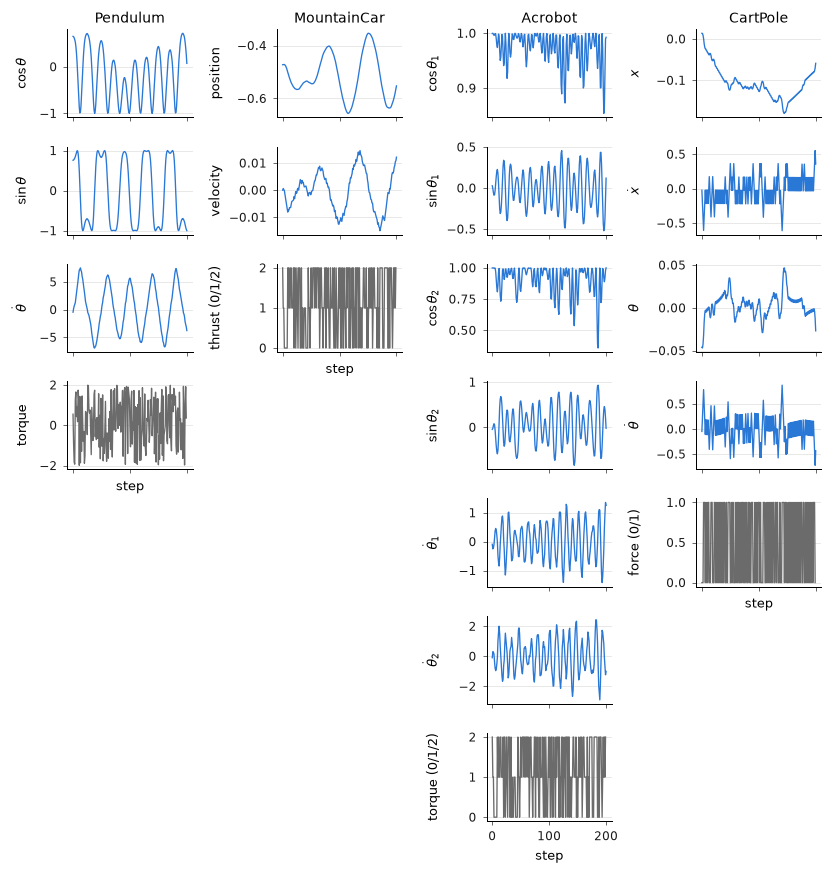

Figure fig1_environments. One episode per environment under a eps-greedy stabiliser / uniform-random policy. Rows are observation channels, the bottom row in each column is the action. The integrated channels (velocities, angular rates) are the ones that must be passed as increments.



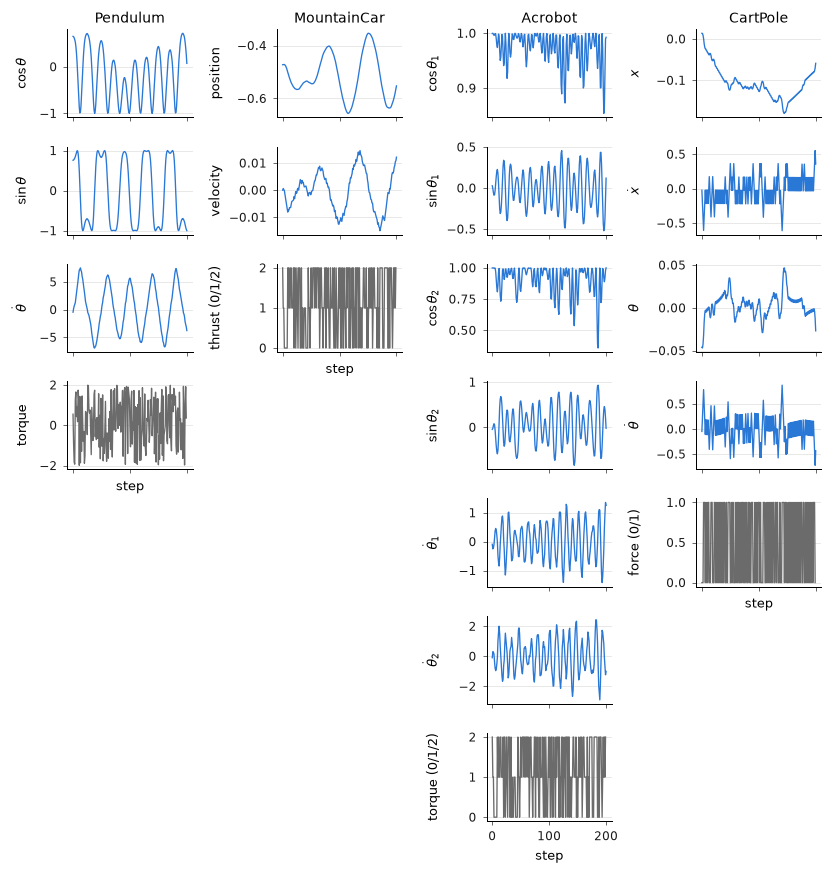

In [2]:
plots.fig_environments(ENVS, FIGDIR)

## 1b  What the model is actually handed

§1 plots the environment as the simulator emits it. Every claim from §2b onwards
is about a *different* array — the one the forecaster receives after the two
transforms, in this order, because `UpsampledDynamics` wraps the model and the
model differences whatever it is given:

1. **stretch** — $r-1$ interpolated steps between real steps, with the action held
   across the sub-steps of the transition it caused;
2. **difference** — the integrated channels handed over as increments.

Holding the action is a zero-order hold, not applying it $r$ times: each sub-step
carries an increment $1/r$ the size of the real one, so what the model reads out
of the context is already "this action accompanies a $1/r$-sized increment". The
scale is learned in-context rather than assumed, which is why the transform adds
no information. The numbers under the figure check that instead of asserting it.

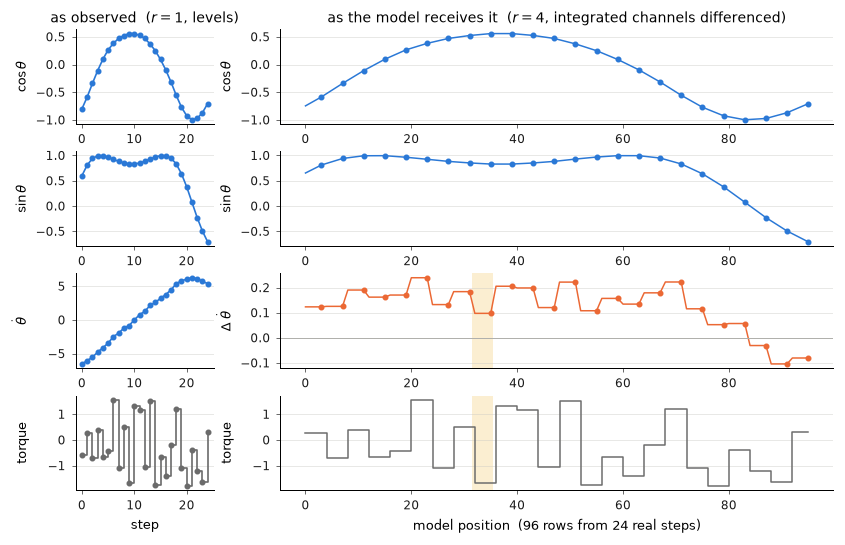

Figure fig1b_model_input. The same 24-step Pendulum window before and after the two transforms, on every channel. Left: the observation as the simulator emits it. Right: the array handed to the forecaster -- stretched by $r=4$ (filled markers are real samples, the line between them is interpolated) and with the integrated channels passed as increments. The action is held across the sub-steps of the transition it caused, which is a zero-order hold, not a repeated application: the sub-step increment shrinks by the same factor. The shaded band is one real transition, spanning the same 4 rows in both panels.

Channel $\dot\theta$: mean |increment| 0.5687 per real step, 0.1422 per model sub-step (ratio 4.00, r = 4).
Action: 0.9793 mean |a| before, 0.9964 after -- unchanged by construction.
So the model reads 'this action accompanies a 4x smaller increment', and it reads that from the context rather than from an assumption about units.


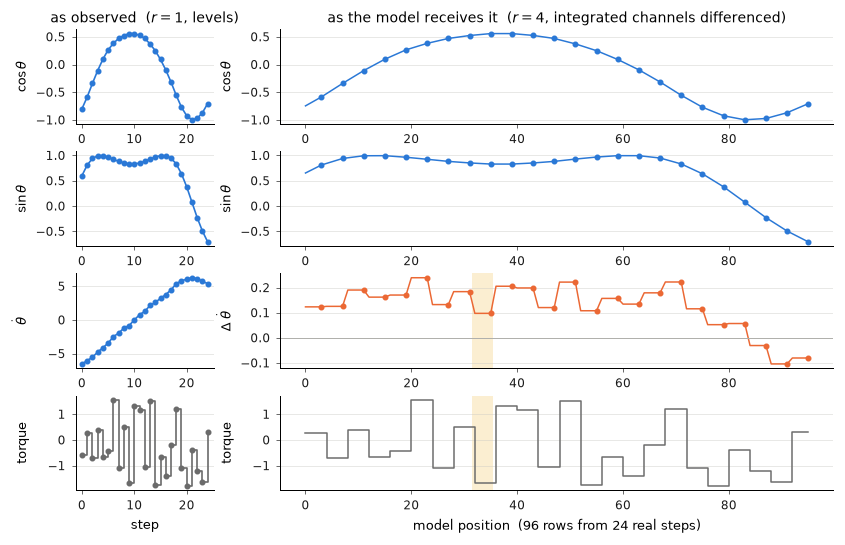

In [ ]:
plots.fig_model_input(config.ILLUSTRATION_ENV, FIGDIR)

## 2b  Out of the box, and what fixes it

Hold the context fixed, sweep the next action over a grid, and plot how far the
predicted next value moves on the channel the action drives. The dashed reference
is the real environment stepped from the same states. A flat line means the model
forecast the same thing whatever action it was told was coming — not a weak
effect, no effect.

Four presentations of the *same* trajectory:

| | integrated channels | resolution |
|---|---|---|
| **levels** | as observed | as observed |
| **+ differencing** | as increments, re-integrated after | as observed |
| **+ stretching** | as observed | resampled $r$-fold |
| **both** | as increments | resampled $r$-fold |

States, actions and contexts are byte-identical across the four; only the
representation changes, so whatever the panels show is a fact about the model
rather than about the environment. The stretch factor is `config.DEFAULT_R`;
§5 sweeps it properly.

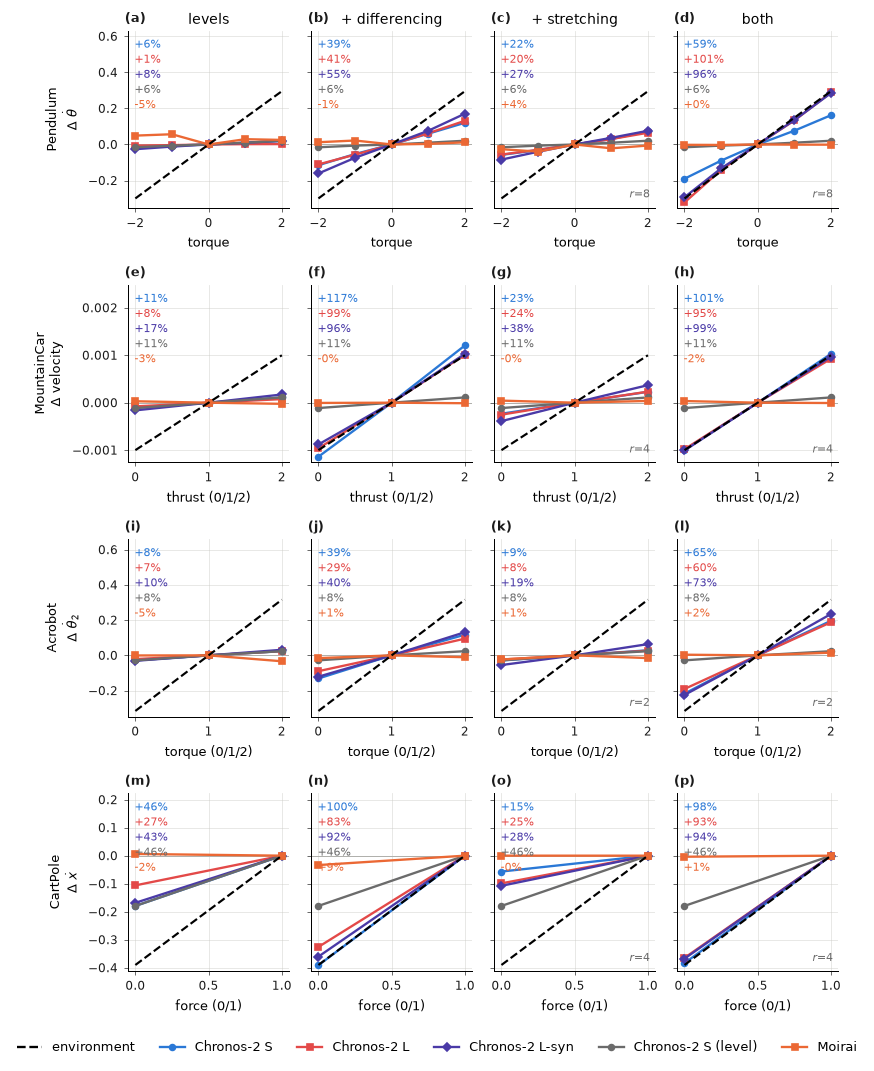

Figure fig2b_transforms. The same probe, the same contexts, the same models -- only the presentation of the trajectory changes. Each panel sweeps the next action and plots the mean shift in the predicted next value, centred on the middle action; the dashed line is the real environment stepped from the same states, so a flat curve means the action was ignored. Percentages are the recovered slope as a share of the environment's, in each model's colour.



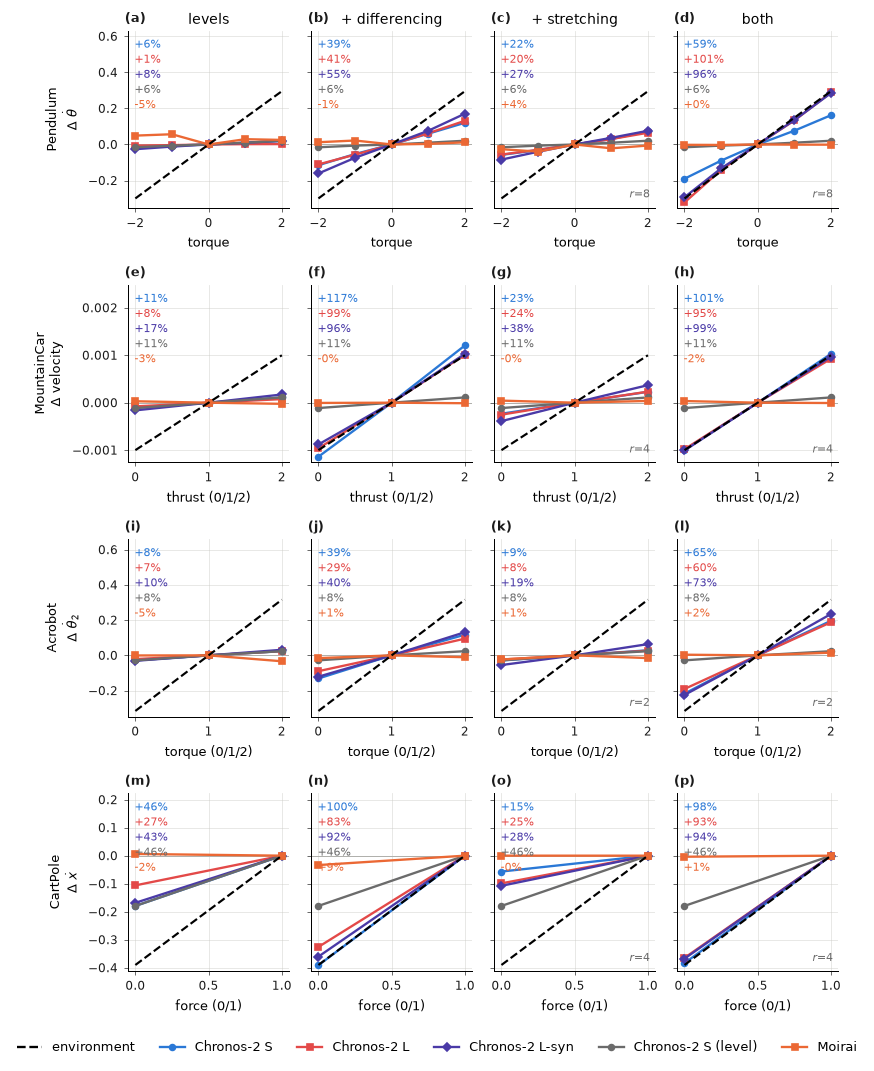

In [16]:
plots.fig_probe(probe, ENVS, FIGDIR)

## 4  What the two transforms do

The mechanism behind §2b, on real data rather than a sketch.

**Differencing.** On levels the previous value already reproduces the series, so
the action is a small fraction of what a forecaster sees; on increments the same
action term is a substantial share of the signal.

**Stretching.** The same physical motion spread across more of the model's patch
grid, so each patch covers a smaller, smoother excursion. The information is
identical — only the resolution changes.

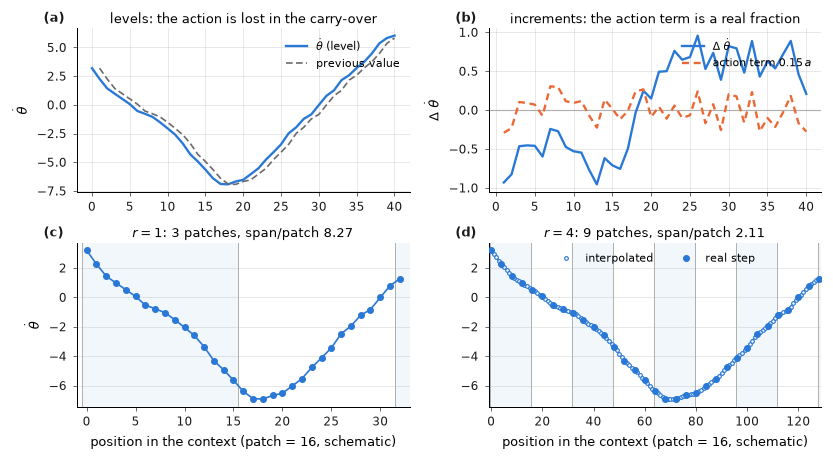

Figure fig4_interventions. The two interventions on real Pendulum data. (a) On levels the previous value already reproduces the series, so the action changes almost nothing a forecaster can see. (b) On increments the same action term is a substantial share of the signal. (c, d) Stretching inserts interpolated steps, so the same physical motion spans more of the patch grid and each patch covers a smaller, smoother excursion.

Action term in the increment: 0.154*a, contributing 0.152 against 0.577 mean |increment| (26%).


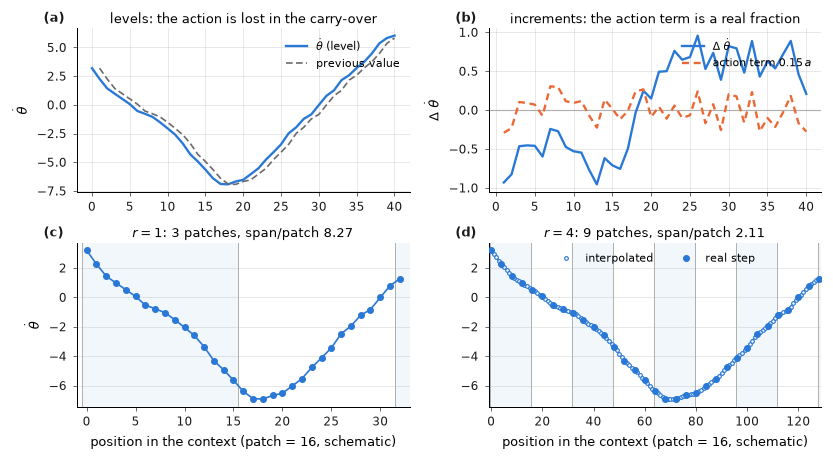

In [5]:
plots.fig_interventions(config.ILLUSTRATION_ENV, FIGDIR)

## 5  Hyperparameter study

Every model, every variant, every budget — one one-step NMSE per cell.

| | the model's hyperparameter | values |
|---|---|---|
| Chronos-2, Moirai | presentation × stretch factor | {levels, differenced} × {1, 2, 4, 8, 16} |
| MLP, VARX | history length | lag 1, 4, 16 |

$N$ means the same thing on both sides — context steps for a foundation model,
training transitions for a fitted one — drawn from episodes of the same length
under the same policy. Stretching does not count against the budget ($N$ real
samples become $(N-1)r+1$ tokens, a processing choice) but it does consume the
context.

The figure sweeps the stretch factor at one budget (`config.STRETCH_BUDGET`), one
curve per model, with the reference model on levels as the dashed open curve. The
table below it is the whole grid; the marked row is the variant §6–§8 use.

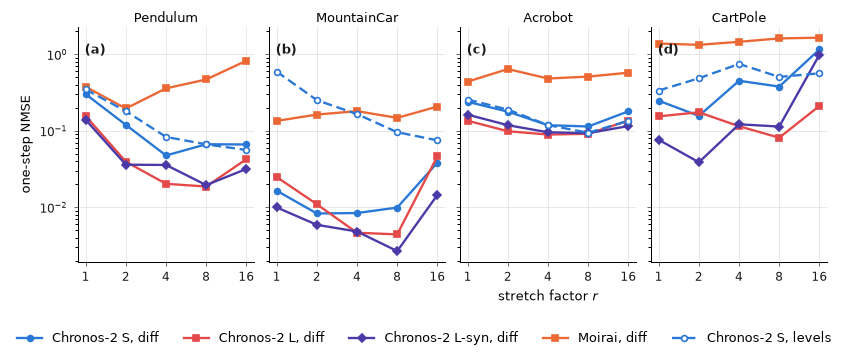

Figure fig5_stretch. One-step error against the stretch factor at $N$=256. Filled markers are the differenced presentation, the open dashed curve is the same model on levels. Stretching is a change of resolution, not of information: N real samples become $(N-1)r+1$ tokens.



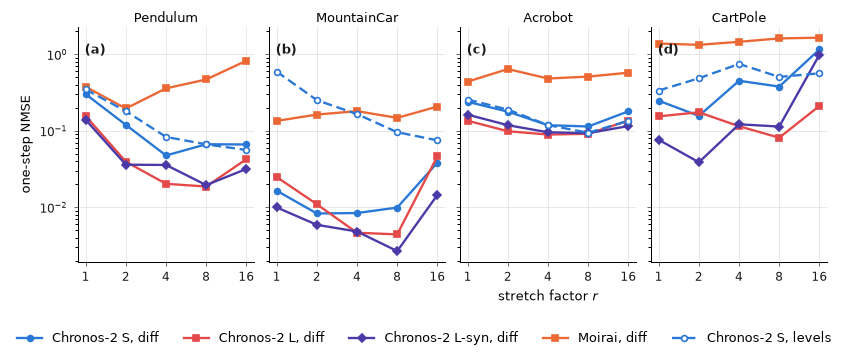

In [6]:
plots.fig_stretch(grid, ENVS, FIGDIR)

A blank cell is a configuration that is **not defined** at that budget,
not one that scored badly: a stretched context that would overflow the model's
window, a VARX with more parameters than design rows, or a Moirai whose context is
shorter than its own horizon requirement — on the `auto` patch path it needs
$(N-1)r+1-d > rH$, so at $N=2$ it runs on levels but not differenced.

In [7]:
for env_id in ENVS:
    print(f"=== {env_id} ===")
    display(tables.show(tables.table_grid(grid, env_id)))

=== Pendulum-v1 ===


=== MountainCar-v0 ===


=== Acrobot-v1 ===


=== CartPole-v1 ===


## 6  Context and data budget

$N$ swept from a single sample to a full context, each model in the configuration
§5 selected, so a panel carries a handful of curves instead of forty. For the
foundation models $N$ is the whole context, for the others the number of
transitions fitted on. The models drawn are `config.PLOT_MODELS`.

Read it for **where the curves cross**: that is the number of transitions the
pretrained model saves you, and it is the one number here a practitioner can act
on directly.

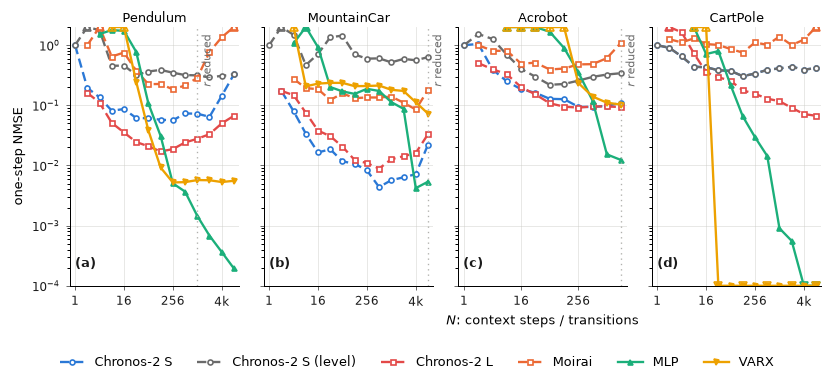

Figure fig6_scaling. How much data each model gets, on one axis, each model in the configuration selected by the hyperparameter study. For the foundation models $N$ is the whole context; for the others it is the number of transitions fitted on, drawn from episodes of the same length under the same policy.



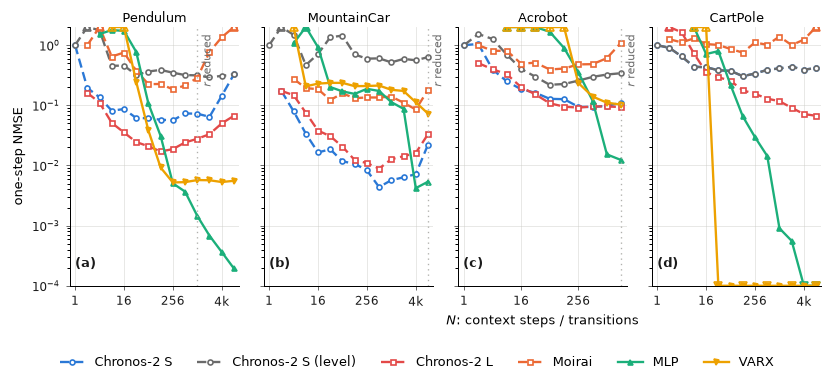

In [14]:
plots.fig_scaling(scaling, ENVS, FIGDIR)

## 7  Multi-step rollout

Open loop to $h=20$ with the true action sequence known throughout — the
favourable case for every model — repeated at three data budgets, because "which
model rolls out best" has no answer independent of how much data each model had.

Normalisation is per horizon by the mean square of $s_{t+h}-s_t$, so persistence
sits at 1 for every $h$: **where a curve crosses that line the model has stopped
being useful for planning**, and that crossing is the number an MPC or Dyna loop
actually needs.

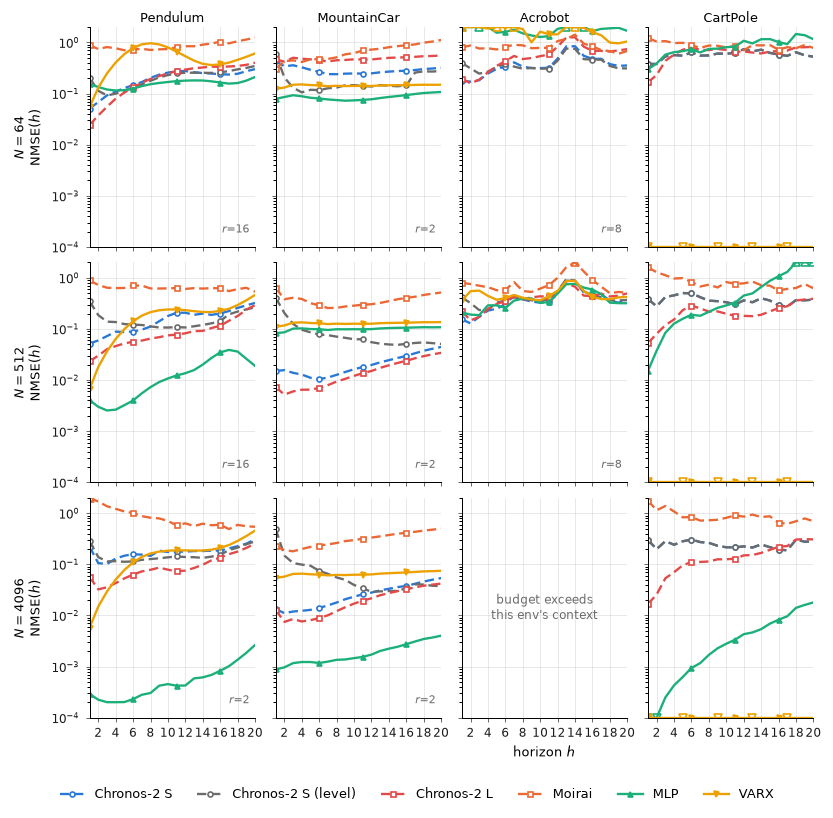

Figure fig7_rollout. Open-loop rollout to $h=20$ with the true actions known, repeated at 3 data budgets, each model in the configuration selected by the hyperparameter study. A row is one budget: the trained models were fitted on $N$ transitions, the foundation models given $N$ steps of context, stretched by the $r$ printed in each panel.



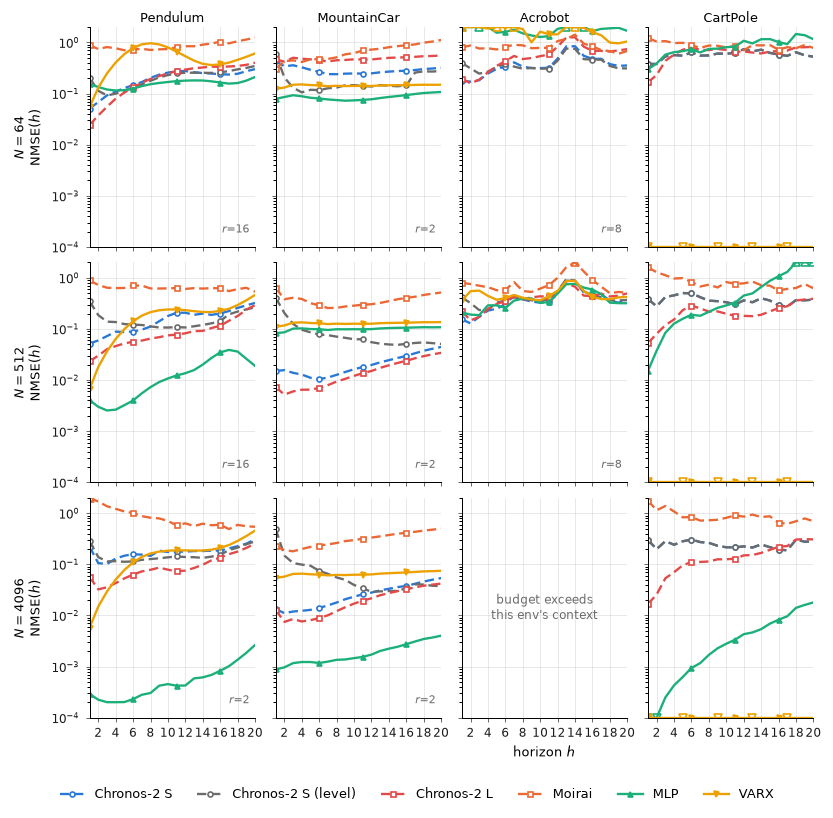

In [9]:
plots.fig_rollout(rollout, ENVS, FIGDIR)

## 8  The rollout as states

The same rollout as §7, but plotted as the states themselves. An error curve says
how wrong a model is; this says *how* — a phase lag, a damped amplitude and a
drift off the manifold all look alike in NMSE and quite different here. Black is
the environment, dashed is each model, one panel row per observation channel.

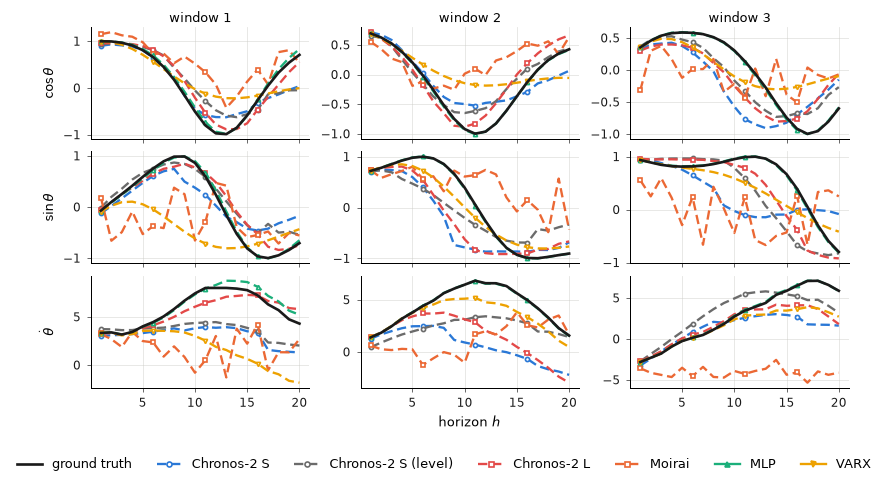

Figure fig8_trajectories_pendulum. Open-loop rollout on Pendulum as states rather than as an error, at $N$=4096 with the true actions known throughout. Black is the environment, dashed is each model. Rows are observation channels, columns are windows from the same evaluation set section 7 scores.



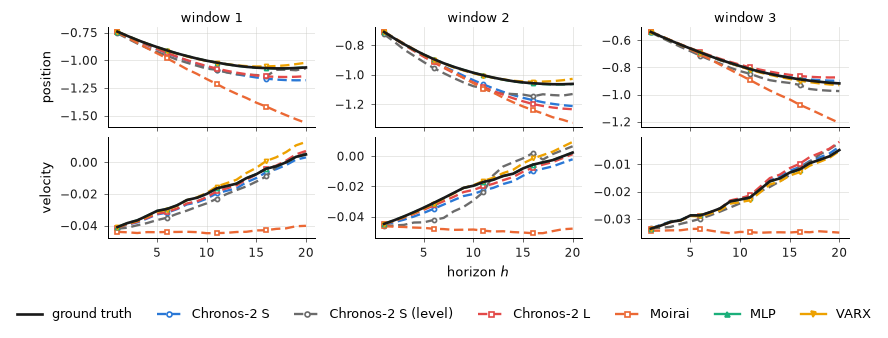

Figure fig8_trajectories_mountaincar. Open-loop rollout on MountainCar as states rather than as an error, at $N$=4096 with the true actions known throughout. Black is the environment, dashed is each model. Rows are observation channels, columns are windows from the same evaluation set section 7 scores.



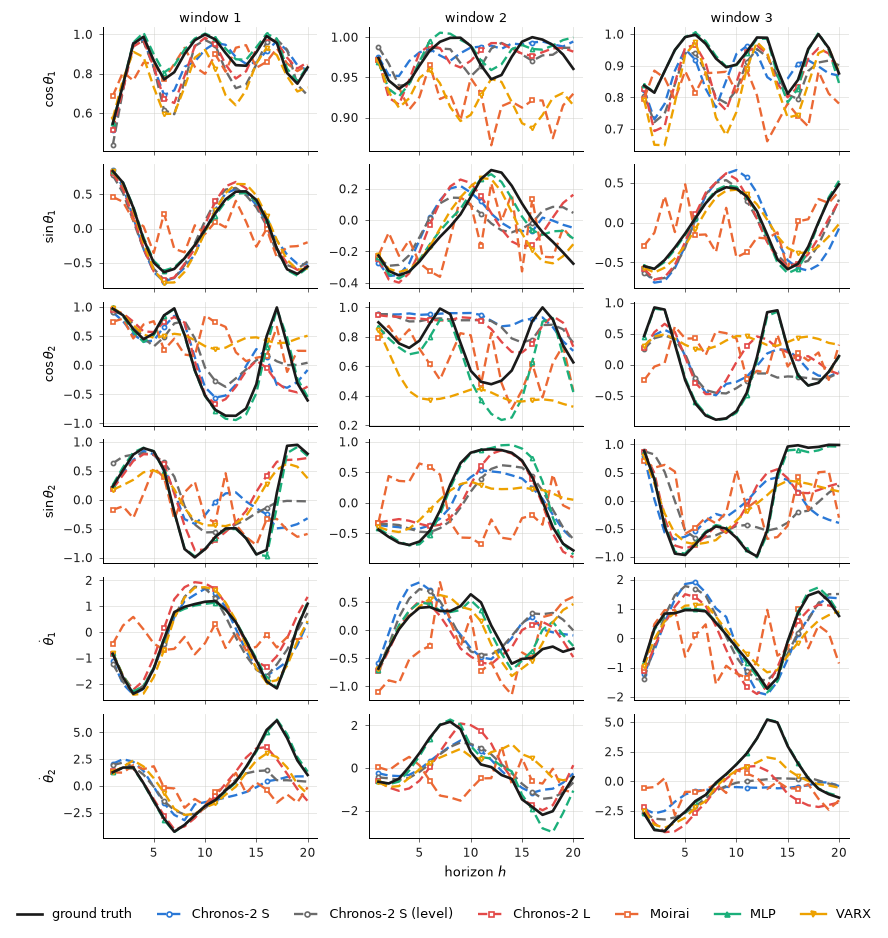

Figure fig8_trajectories_acrobot. Open-loop rollout on Acrobot as states rather than as an error, at $N$=4096 with the true actions known throughout. Black is the environment, dashed is each model. Rows are observation channels, columns are windows from the same evaluation set section 7 scores.



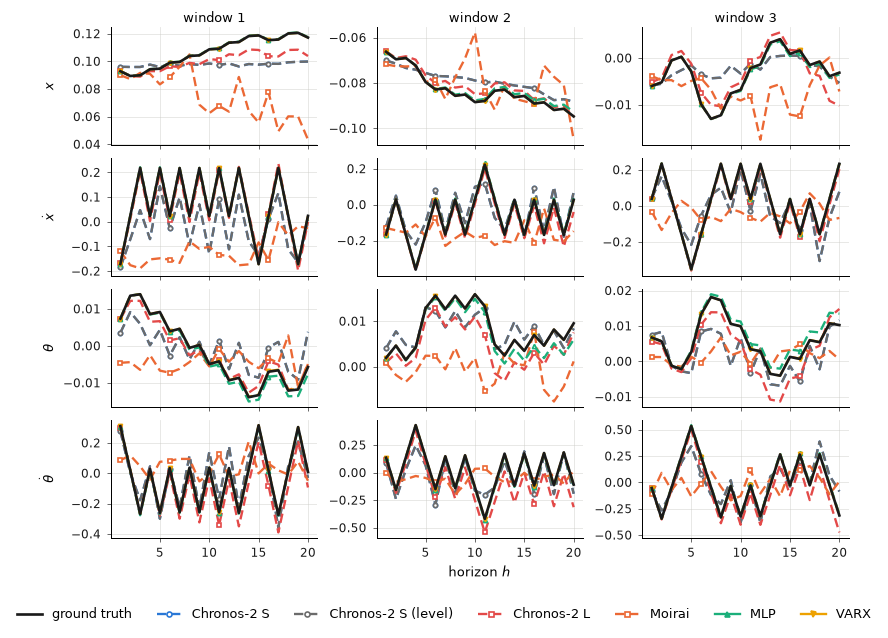

Figure fig8_trajectories_cartpole. Open-loop rollout on CartPole as states rather than as an error, at $N$=4096 with the true actions known throughout. Black is the environment, dashed is each model. Rows are observation channels, columns are windows from the same evaluation set section 7 scores.



In [10]:
for env_id in ENVS:
    plots.fig_trajectories(traj, env_id, FIGDIR)